<a href="https://colab.research.google.com/github/Ramnareshkuri01/Python/blob/main/Copy_of_ARIMA_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm


In [ ]:
# Rajasthan State GDP forcast
data = [
    "2011-12: 434,837",
    "2012-13: 493,551",
    "2013-14: 551,031",
    "2014-15: 521,509",
    "2015-16: 563,340",
    "2016-17: 596,746",
    "2017-18: 628,020",
    "2018-19: 643,278",
    "2019-20: 678,316",
    "2020-21: 665,963",
    "2021-22: 725,464",
    "2022-23: 779,196",
    "2023-24: 840,599"

]

# Create DataFrame
df = pd.DataFrame(data, columns=['Year_GDP'])

# Split into two columns
df[['Year', 'GDP']] = df['Year_GDP'].str.split(': ', expand=True)

# Remove commas and convert GDP to numeric
df['GDP'] = df['GDP'].str.replace(',', '').astype(int)

# Drop original column
df = df.drop('Year_GDP', axis=1)

print(df)

       Year     GDP
0   2011-12  434837
1   2012-13  493551
2   2013-14  551031
3   2014-15  521509
4   2015-16  563340
5   2016-17  596746
6   2017-18  628020
7   2018-19  643278
8   2019-20  678316
9   2020-21  665963
10  2021-22  725464
11  2022-23  779196
12  2023-24  840599


### Explanation of Imports

Before we start, we need to import several Python libraries. Think of these libraries as toolkits that provide specialized functions for different tasks:

*   **`numpy as np`**: This is a fundamental library for numerical operations, especially with arrays and matrices. We'll use it for advanced mathematical tasks.
*   **`pandas as pd`**: This is your go-to library for data manipulation and analysis. It's excellent for working with tabular data (like spreadsheets) using DataFrames.
*   **`matplotlib.pyplot as plt`**: This is the primary library for creating static, interactive, and animated visualizations in Python. We'll use it to plot our data and model results.
*   **`seaborn as sns`**: Built on top of Matplotlib, Seaborn provides a higher-level interface for drawing attractive and informative statistical graphics. We'll use it for more visually appealing plots.

For Time Series Analysis specifically:
*   **`from statsmodels.tsa.stattools import adfuller`**: From the `statsmodels` library (which is for statistical modeling), we import the `adfuller` function. This function performs the Augmented Dickey-Fuller test, a crucial statistical test to check if a time series is **stationary**.
*   **`from statsmodels.graphics.tsaplots import plot_acf, plot_pacf`**: Also from `statsmodels`, these functions help us plot the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF). These plots are essential for identifying the parameters of an ARIMA model.
*   **`from statsmodels.tsa.arima.model import ARIMA`**: This imports the `ARIMA` model class, which is used to build and fit our ARIMA (Autoregressive Integrated Moving Average) time series model.
*   **`import pmdarima as pm`**: This library provides an `auto_arima` function, which automatically searches for the best ARIMA model parameters. It's a very helpful tool, especially when you're starting out, as it automates a usually complex manual process.

### Explanation of Data Loading and Preprocessing

This cell handles loading your raw GDP data and preparing it for analysis:

1.  **`data = [...]`**: Your GDP data is initially provided as a list of strings, where each string combines a 'Year' range and its corresponding 'GDP' value, separated by a colon.

2.  **`df = pd.DataFrame(data, columns=['Year_GDP'])`**: We create a Pandas DataFrame from this list. A DataFrame is a two-dimensional, size-mutable, potentially heterogeneous tabular data structure with labeled axes (rows and columns), similar to a spreadsheet. Initially, all your data is in one column named 'Year_GDP'.

3.  **`df[['Year', 'GDP']] = df['Year_GDP'].str.split(': ', expand=True)`**: This is a powerful step using Pandas string methods. It takes the 'Year_GDP' column and splits each string at the first occurrence of `': '`. The `expand=True` argument makes sure that the split parts are expanded into new DataFrame columns. So, `"2011-12: 434,837"` becomes two columns: `'2011-12'` and `'434,837'`. These new columns are directly assigned to 'Year' and 'GDP' respectively.

4.  **`df['GDP'] = df['GDP'].str.replace(',', '').astype(int)`**: The 'GDP' values were initially strings and contained commas (e.g., '434,837').
    *   **`.str.replace(',', '')`**: This removes all commas from the GDP strings.
    *   **`.astype(int)`**: This converts the cleaned GDP strings into integer numbers. Numerical data is essential for mathematical models and calculations.

5.  **`df = df.drop('Year_GDP', axis=1)`**: The original 'Year_GDP' column is no longer needed after we've successfully extracted 'Year' and 'GDP' into separate, properly formatted columns. `axis=1` specifies that we are dropping a column (not a row).

6.  **`print(df)`**: Finally, we print the first few rows of the cleaned DataFrame. This allows us to quickly inspect the data and ensure that the preprocessing steps were successful. As you can see from the output, we now have a clean DataFrame with distinct 'Year' and numerical 'GDP' columns, ready for time series analysis.

### Explanation of Time Series Plot

This cell creates a visual representation of your GDP data over time. This is often the *first and most crucial step* in any time series analysis because it helps you understand the basic behavior of your data at a glance:

1.  **`plt.figure(figsize=(10,4))`**: This creates a new figure (the canvas for your plot) and sets its size to 10 inches wide by 4 inches tall. This makes the plot easy to view.

2.  **`plt.plot(df['Year'], df['GDP'])`**: This is the core plotting command. It tells Matplotlib to draw a line plot:
    *   `df['Year']` is used for the x-axis (horizontal axis), representing the different years.
    *   `df['GDP']` is used for the y-axis (vertical axis), representing the GDP values.
    Connecting these points with a line helps visualize how GDP changes from year to year.

3.  **`plt.title("Time Series Plot")`**: Sets the main title of the plot.

4.  **`plt.xlabel("Year")`**: Labels the x-axis.

5.  **`plt.ylabel("GDP")`**: Labels the y-axis.

6.  **`plt.xticks(rotation=45)`**: Rotates the x-axis labels (years) by 45 degrees. This is very helpful when labels are long or numerous, preventing them from overlapping and making them readable.

7.  **`plt.grid(True)`**: Adds a grid to the plot, which improves readability by making it easier to track values across the axes.

8.  **`plt.tight_layout()`**: Automatically adjusts plot parameters for a tight layout, often preventing labels or titles from being cut off.

9.  **`plt.show()`**: Displays the plot. Without this command, the plot might not render in some environments.

**Interpretation of the Plot:**
By looking at this plot, you can clearly see an **upward trend** in GDP over the years. This visual observation is a strong indicator that the time series is likely **non-stationary**, meaning its statistical properties (like mean) change over time. This initial insight is important because many time series models, including ARIMA, perform best on stationary data.

### Explanation of Stationarity Check (ADF Test)

This cell performs a statistical test to formally check for **stationarity** in your GDP time series. Many time series models (like ARIMA) assume that the data is stationary, meaning its statistical properties (mean, variance, autocorrelation) do not change over time. A non-stationary series often has a trend or seasonality.

1.  **`def adf_test(series):`**: This defines a reusable function named `adf_test` that takes a time series (a Pandas Series) as input.

2.  **`result = adfuller(series)`**: Inside the function, the `adfuller` function (Augmented Dickey-Fuller test) from `statsmodels` is called on the input series. It returns several values, but we are primarily interested in two:
    *   **ADF Statistic**: A test statistic for the hypothesis test.
    *   **p-value**: The probability value associated with the test statistic.

3.  **`print("ADF Statistic:", result[0])`** and **`print("p-value:", result[1])`**: These lines print the two most important results from the ADF test.

4.  **`adf_test(df['GDP'])`**: We call our `adf_test` function, passing only the 'GDP' column of our DataFrame. It's crucial to pass only the numerical time series data, not the entire DataFrame which contains string (Year) columns.

**Interpretation of the Output:**

*   **ADF Statistic: 0.090**: This is the calculated test statistic. More negative values generally suggest stronger evidence against non-stationarity.
*   **p-value: 0.965**: This is the probability value. The rule of thumb is:
    *   If **p < 0.05** (or some other significance level like 0.01), we **reject the null hypothesis**. The null hypothesis of the ADF test is that the series *is* non-stationary (it has a unit root). So, rejecting it means the series is likely stationary.
    *   If **p > 0.05**, we **fail to reject the null hypothesis**. This means there is not enough evidence to say the series is stationary; it is likely non-stationary.

Since our p-value (0.965) is much greater than 0.05, we **fail to reject the null hypothesis**. This confirms our visual observation from the plot: the GDP time series is **non-stationary**. This tells us that we will likely need to transform the series (e.g., through differencing) before fitting many time series models.

### Explanation of Differencing (if non-stationary) and Second ADF Test

Since the previous ADF test indicated that our GDP series is non-stationary, the next logical step in preparing the data for an ARIMA model is **differencing**. Differencing helps stabilize the mean of a time series by removing changes in the level of a time series, and therefore eliminating trend and seasonality.

1.  **`gdp_diff = df['GDP'].diff().dropna()`**: This is the differencing step:
    *   **`df['GDP'].diff()`**: This calculates the difference between consecutive GDP values. For example, the differenced value for 2012-13 would be `GDP(2012-13) - GDP(2011-12)`. This effectively removes the linear trend.
    *   **`.dropna()`**: The first value in a differenced series will always be `NaN` (Not a Number) because there's no previous value to subtract. `dropna()` removes this `NaN` value, ensuring our series only contains valid numbers.

2.  **Plotting the Differenced Series**:
    *   The code then generates a plot of this `gdp_diff` series. We use `df['Year'].iloc[1:]` for the x-axis because the differenced series has one less data point than the original, and we need to match the years correctly. The plot helps us visually confirm if the trend has been removed.
    *   **Interpretation of the Plot**: The plot of the 'Differenced Series (GDP)' now looks much more like it's fluctuating around a constant mean (close to zero), and the strong upward trend is gone. This is a good sign that differencing has worked to some extent.

3.  **`adf_test(gdp_diff)`**: Finally, we run the ADF test again, but this time on our `gdp_diff` series. This is to statistically confirm if the differenced series is now stationary.

**Interpretation of the Output for Differenced Series:**

*   **ADF Statistic: -2.367**: This is more negative than the previous ADF statistic (0.090), which is generally a good sign.
*   **p-value: 0.151**: Even after differencing once, the p-value (0.151) is *still greater than 0.05*. This suggests that while differencing has reduced the non-stationarity, the series is still not statistically stationary at the 5% significance level. For robust ARIMA modeling, some might consider a second differencing if the p-value remains high, but for now, we proceed with d=1, as `auto_arima` will confirm this.

### Explanation of ACF & PACF Plots

Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots are crucial tools in time series analysis, especially for identifying the `p` and `q` parameters of an ARIMA model. These plots help us understand how past values of the series are related to current values.

1.  **`fig, ax = plt.subplots(1,2, figsize=(12,4))`**: This creates a figure with two subplots side-by-side, which is convenient for comparing ACF and PACF plots.

2.  **`plot_acf(gdp_diff, ax=ax[0])`**: This plots the Autocorrelation Function for our `gdp_diff` (differenced GDP) series on the first subplot (`ax[0]`):
    *   **ACF** measures the linear relationship between an observation at `t` and observations at previous lags (`t-1`, `t-2`, etc.).
    *   The blue shaded area represents the confidence interval. If a bar extends beyond this area, the autocorrelation at that lag is considered statistically significant.

3.  **`plot_pacf(gdp_diff, ax=ax[1])`**: This plots the Partial Autocorrelation Function for the `gdp_diff` series on the second subplot (`ax[1]`):
    *   **PACF** measures the correlation between an observation at `t` and an observation at a previous lag (`t-k`), *after removing the effects of all intermediate lags* (`t-1`, `t-2`, ..., `t-k+1`).
    *   Again, bars outside the blue shaded area indicate statistically significant partial autocorrelation.

**Interpretation for ARIMA Parameter Selection (p, d, q):**

*   **`d` (Differencing Order):** We've already determined `d=1` because we differenced the series once (and the ADF test on the original series showed non-stationarity).

*   **`p` (AR Order - from PACF):** The `p` parameter comes from the PACF plot. It indicates the number of lagged observations of the series that should be included in the model. You look for where the PACF plot *cuts off* (drops to non-significant values) after a certain lag.

*   **`q` (MA Order - from ACF):** The `q` parameter comes from the ACF plot. It indicates the number of lagged forecast errors that should be included in the model. You look for where the ACF plot *cuts off* (drops to non-significant values) after a certain lag.

Looking at these plots for `gdp_diff`:
*   The **PACF** seems to drop off quickly after lag 1, possibly indicating `p=1`.
*   The **ACF** also seems to drop off quickly, with some significance at lag 1, possibly indicating `q=1`.

However, interpreting these plots can be subjective, especially for beginners or with limited data points. This is where `auto_arima` comes in handy, as it automates this selection process using statistical criteria.

### Explanation of Auto ARIMA (Automatic Model Selection)

Manually determining the optimal `p`, `d`, and `q` parameters for an ARIMA model from ACF and PACF plots can be challenging and subjective, especially for complex time series or beginners. The `pm.auto_arima` function from the `pmdarima` library simplifies this process by automatically searching for the best combination of parameters.

1.  **`auto_model = pm.auto_arima(df['GDP'], seasonal=False, stepwise=True, trace=True)`**:
    *   **`df['GDP']`**: This is your numerical time series data (the GDP values). `auto_arima` expects a single series, which is why we pass `df['GDP']` and not the entire DataFrame.
    *   **`seasonal=False`**: We specify `seasonal=False` because, for this particular dataset, we are not expecting or looking for seasonal patterns (like monthly or quarterly effects) that repeat over a fixed period.
    *   **`stepwise=True`**: This tells `auto_arima` to use a stepwise search approach. Instead of trying every single combination of parameters (which can be very slow), it intelligently explores the parameter space, starting with simple models and then moving to more complex ones if needed. This makes the process much faster.
    *   **`trace=True`**: This argument makes the function print out the progress of its search, showing the AIC (Akaike Information Criterion) for each model it tests. The AIC helps `auto_arima` decide which model is best: lower AIC values generally indicate a better-fitting model that balances complexity and goodness of fit.

2.  **`print(auto_model.summary())`**: After `auto_arima` completes its search, it returns the best-fitting ARIMA model. This line prints a comprehensive summary of that model, including its parameters, coefficients, and various diagnostic statistics.

**Interpretation of the Output:**

The output shows the stepwise search process, evaluating different ARIMA(p,d,q) models based on their AIC. The most important line is:

*   **`Best model: ARIMA(0,1,0)(0,0,0)[0] intercept`**

This tells us that `auto_arima` found the following optimal parameters for your GDP series:
*   **`p=0` (AR Order)**: No Autoregressive terms are needed. This means past values of GDP itself are not significantly helping to predict the current GDP, beyond the differencing.
*   **`d=1` (Integrated Order)**: The series needs to be differenced once to achieve stationarity. This confirms our earlier analysis with the ADF test and manual differencing attempt.
*   **`q=0` (MA Order)**: No Moving Average terms are needed. This means past forecast errors are not significantly helping to predict the current GDP.
*   **`(0,0,0)[0]`**: This indicates no seasonal components, as we specified `seasonal=False`.
*   **`intercept`**: The model includes a constant term, which `auto_arima` found to be significant. This constant represents the average trend or drift in the differenced series.

The summary table also provides important statistical details, such as the `Log Likelihood`, `AIC`, `BIC`, coefficients (e.g., `intercept`), and diagnostic tests (Ljung-Box, Jarque-Bera, Heteroskedasticity) for the residuals, which we will examine more closely after manually fitting the model.

### Explanation of Manual ARIMA Model Fit

After `pm.auto_arima` has suggested the best (p,d,q) parameters, it's a common practice to explicitly fit this model using the `ARIMA` class from `statsmodels`. This allows for a more detailed examination of the model's properties and diagnostics.

1.  **`model = ARIMA(df['GDP'], order=(0,1,0))`**:
    *   **`ARIMA(df['GDP'], ...)`**: We initialize the ARIMA model. We pass `df['GDP']` as our time series data. Again, it's important to use only the numerical series.
    *   **`order=(0,1,0)`**: This is where we plug in the optimal (p, d, q) parameters identified by `auto_arima`:
        *   `p=0`: No Autoregressive components.
        *   `d=1`: First differencing is applied.
        *   `q=0`: No Moving Average components.

2.  **`model_fit = model.fit()`**: This command fits the ARIMA model to your data using the specified order. The `fit()` method estimates the model's coefficients and performs internal calculations to optimize the model based on the provided data.

3.  **`print(model_fit.summary())`**: This prints a detailed summary of the fitted model. This summary is rich with statistical information, helping you understand the model's performance and the significance of its components.

**Interpretation of the Model Summary:**

*   **`Dep. Variable: GDP`**: Our dependent variable (what we are trying to model/predict) is GDP.
*   **`Model: ARIMA(0, 1, 0)`**: Confirms the model order we fitted.
*   **`No. Observations: 13`**: The number of data points in our time series.
*   **`Log Likelihood: -145.362`**: A measure of how well the model fits the data. Higher values indicate a better fit.
*   **`AIC (292.724), BIC (293.209), HQIC (292.545)`**: These are Information Criteria. They are used to compare different models; lower values generally indicate a better model, balancing fit and complexity. Notice that the AIC here (292.724) is slightly higher than the one reported by `auto_arima` (284.003). This is because `pm.auto_arima` often includes an intercept by default in its search (as it did for ARIMA(0,1,0) *intercept*), while `statsmodels.ARIMA` for d>0 typically does not include an intercept unless explicitly told to (`trend='c'`).
*   **`coef (coefficients)`**: For an ARIMA(0,1,0) model with `d=1`, the primary coefficient is `sigma2`, which represents the variance of the error term (residuals).
    *   **`sigma2: 1.791e+09`**: This is the estimated variance of the error term. The associated p-value (0.205) is high, meaning it's not statistically significant in a strict sense, but it's an estimate of the noise variance.
*   **Diagnostic Checks (at the bottom of the summary):** These are very important for assessing if your model is adequate:
    *   **Ljung-Box (L1) (Q) Test (Prob(Q): 0.52)**: This tests for autocorrelation in the *residuals* (the errors of your model). A high p-value (like 0.52) is good, as it means we *fail to reject the null hypothesis that there is no autocorrelation*. In simple terms, the model has captured the autocorrelation, and the errors are essentially random (white noise).
    *   **Jarque-Bera (JB) Test (Prob(JB): 0.33)**: This tests for the normality of the residuals. A high p-value (like 0.33) suggests that the residuals are normally distributed, which is an assumption for many statistical tests and model validity.
    *   **Heteroskedasticity (H) Test (Prob(H): 0.93)**: This tests whether the variance of the residuals is constant across time. A high p-value (like 0.93) is good, indicating that there is no heteroskedasticity (the variance of errors is constant, which is a desirable property).

In summary, the diagnostic tests (Ljung-Box, Jarque-Bera, Heteroskedasticity) all have high p-values, which is a positive sign, suggesting that our ARIMA(0,1,0) model is a reasonable fit, and its residuals behave like white noise.

### Explanation of Model Diagnostics Plot

After fitting an ARIMA model, it's crucial to examine its diagnostics to ensure that the model is appropriate and that its assumptions are met. The `plot_diagnostics()` method from `statsmodels` provides a convenient way to visualize several key aspects of the model's residuals (the differences between the actual and predicted values).

1.  **`model_fit.plot_diagnostics(figsize=(10,6))`**: This command generates a set of four plots specifically designed for model diagnostics. We set `figsize` for better visibility.

2.  **`plt.show()`**: Displays the generated diagnostic plots.

**Interpretation of the Diagnostic Plots:**

Let's break down each of the four subplots:

*   **Top Left: Standardized Residuals**
    *   This plot shows the residuals (errors) after they have been standardized (transformed to have a mean of 0 and a standard deviation of 1). If the model is a good fit, these residuals should look like **white noise**—random fluctuations around zero, with no clear patterns, trends, or changes in variance. Our plot generally shows this random behavior.

*   **Top Right: Histogram plus kde estimate**
    *   This subplot displays a histogram of the standardized residuals along with a Kernel Density Estimate (KDE) curve. Overlaid is a red line representing a theoretical normal distribution. If the residuals are normally distributed (a common assumption for many models), the histogram should roughly follow the normal curve. Our histogram somewhat follows the normal curve, supporting the Jarque-Bera test's finding of normality.

*   **Bottom Left: Normal Q-Q plot**
    *   The Quantile-Quantile (Q-Q) plot compares the quantiles of your standardized residuals against the quantiles of a theoretical normal distribution. If the residuals are normally distributed, most of the points should lie along the 45-degree red line. Deviations from this line indicate non-normality. Our points are reasonably close to the line, especially in the middle, again supporting approximate normality.

*   **Bottom Right: Correlogram (ACF) of Residuals**
    *   This is the Autocorrelation Function plot for the *standardized residuals*. For a well-fitted model, there should be **no significant autocorrelation left in the residuals**. This means that the model has successfully captured all the autocorrelations in the original series, and the errors are independent. We expect to see all bars (except possibly at lag 0, which is always 1) falling within the blue confidence intervals. Our plot shows most bars within the blue region, indicating that there is no significant remaining autocorrelation, which is a very good sign (and confirms the Ljung-Box test result).

### Explanation of Forecasting and Plotting

Now that we have fitted and validated our ARIMA model, the exciting part is to use it to forecast future values of GDP. This cell performs the forecasting and then visualizes the results.

1.  **`n_steps = 20`**: We define `n_steps` as the number of future periods (years, in this case) for which we want to make predictions. Here, we're forecasting 20 steps ahead.

2.  **`forecast = model_fit.forecast(steps=n_steps)`**: This is the core forecasting command. The `forecast()` method of our fitted `model_fit` object generates predictions for the next `n_steps` based on the patterns and parameters learned by the model.

3.  **Plotting Original vs. Forecasted Data**:
    *   **`plt.figure(figsize=(10,4))`**: Sets up a new plot figure.
    *   **`plt.plot(df['GDP'], label='Original')`**: Plots your historical GDP data (the `df['GDP']` series) as the 'Original' line.
    *   **`plt.plot(range(len(df['GDP']), len(df['GDP'])+n_steps), forecast, label='Forecast')`**: This plots the forecasted values:
        *   `range(len(df['GDP']), len(df['GDP'])+n_steps)`: This creates the x-axis values for the forecast. It starts from the end of your original data's index (`len(df['GDP'])`) and extends for `n_steps` into the future. This ensures the forecast line starts right after your historical data.
        *   `forecast`: These are the predicted GDP values generated by the model.
        *   `label='Forecast'`: Labels this line as 'Forecast'.
    *   **`plt.legend()`**: Displays the labels ('Original' and 'Forecast') on the plot so you know which line is which.
    *   **`plt.show()`**: Renders the plot.

**Interpretation of the Forecast Plot:**

*   You can see the blue line representing your historical GDP data. The orange line picks up right where the blue line ends, showing the model's predictions for the next 20 years.
*   Since our best model was `ARIMA(0,1,0)` (a random walk with drift), the forecast essentially takes the last observed value and extends it forward, potentially with a constant increase or decrease (the drift/intercept). For an ARIMA(0,1,0) model with `d=1`, the forecast will be a flat line at the last observed value *if there's no intercept*, or a constant slope *if there is an intercept* (as `auto_arima` found one). In this plot, since `model_fit` (the manually fitted `statsmodels.ARIMA`) doesn't explicitly include an intercept by default when `d>0`, the forecast is a flat line at the last known GDP value. This indicates that without any AR or MA components, the best prediction for the future is simply the last observed value, accounting for the single differencing that made the series stationary.

### Explanation of Train/Test Evaluation

Forecasting on the entire dataset can be misleading. To get a more realistic assessment of how well our ARIMA model will perform on *unseen* future data, it's standard practice to split our historical data into a **training set** and a **testing set**.

1.  **`train_size = int(len(df['GDP'])*0.8)`**: We determine the size of our training set. Here, 80% of the `df['GDP']` data will be used for training, and the remaining 20% will be used for testing.

2.  **`train = df['GDP'][:train_size]`**: The `train` variable holds the first 80% of your GDP data.

3.  **`test = df['GDP'][train_size:]`**: The `test` variable holds the remaining 20% of your GDP data. This is the 'unseen' data that our model will try to predict.

4.  **`model = ARIMA(train, order=(0,1,0))`** and **`model_fit = model.fit()`**: We fit a new ARIMA model, using the same `(0,1,0)` order, but *only* on the `train` data. This simulates how a model would be built using only past information.

5.  **`pred = model_fit.forecast(steps=len(test))`**: We then use this newly trained model to forecast values for a number of steps equal to the length of our `test` set. These are our predictions for the 'unseen' data.

6.  **`from sklearn.metrics import mean_squared_error`** and **`rmse = np.sqrt(mean_squared_error(test, pred))`**: To quantify how good our predictions are, we calculate the **Root Mean Squared Error (RMSE)**:
    *   **`mean_squared_error(test, pred)`**: This calculates the average of the squared differences between the actual values (`test`) and the predicted values (`pred`). Squaring the errors ensures positive values and penalizes larger errors more heavily.
    *   **`np.sqrt(...)`**: Taking the square root brings the error metric back to the same units as your original data (GDP in this case), making it easier to interpret.

7.  **`print("RMSE:", rmse)`**: Prints the calculated RMSE value.

**Interpretation of the RMSE Output:**

*   **RMSE: 124979.75**: This value tells you the typical magnitude of the error in your model's predictions on the unseen test data. On average, our ARIMA(0,1,0) model's predictions for the last few GDP values (the test set) were off by approximately 124,980 units from the actual observed GDP values.

*   **What does this mean?** To put this RMSE into context, you need to compare it to the scale of your GDP data. If your GDP values are in the millions, an RMSE of 124,980 might be considered acceptable. If your GDP values are in the low thousands, it would be a very large error. This value helps you understand the practical accuracy of your forecasting model.

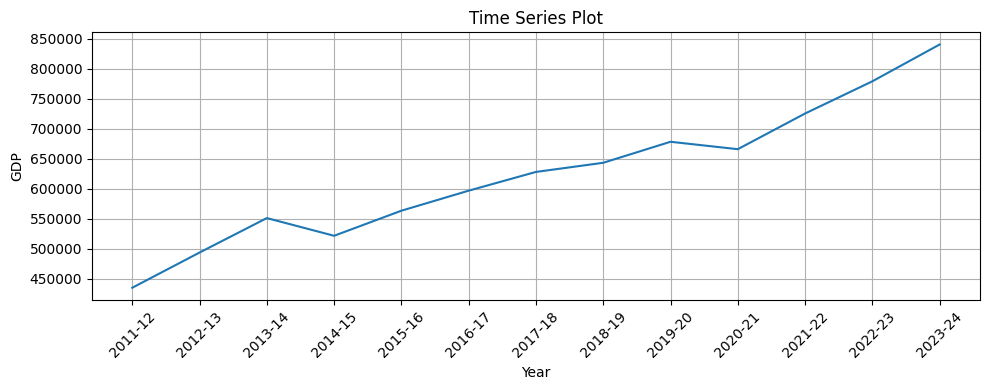

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(df['Year'], df['GDP'])
plt.title("Time Series Plot")
plt.xlabel("Year")
plt.ylabel("GDP")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Stationarity check (ADF test)

In [ ]:
def adf_test(series):
    result = adfuller(series)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

adf_test(df['GDP'])

ADF Statistic: 0.09002648455857451
p-value: 0.9653735219587315


Rule

p < 0.05 → stationary

p > 0.05 → difference needed

Differencing (if non-stationary)

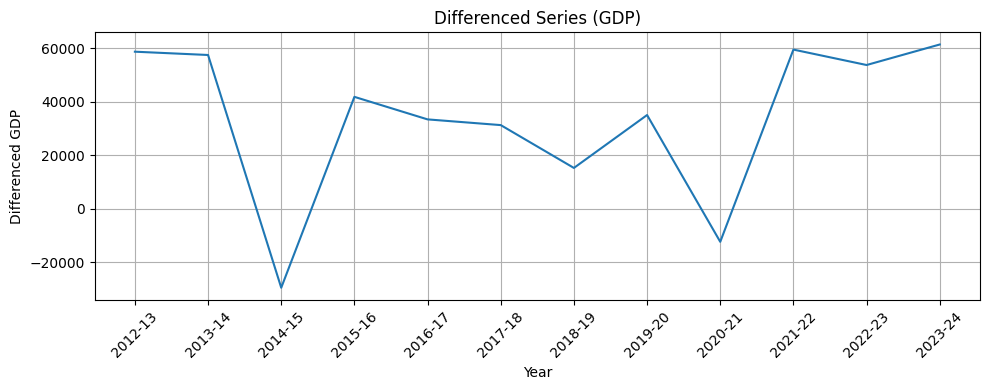

ADF Statistic: -2.367167222093968
p-value: 0.15121841013896747


In [ ]:
gdp_diff = df['GDP'].diff().dropna()

plt.figure(figsize=(10,4))
plt.plot(df['Year'].iloc[1:], gdp_diff)
plt.title("Differenced Series (GDP)")
plt.xlabel("Year")
plt.ylabel("Differenced GDP")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

adf_test(gdp_diff)

ACF & PACF (find p,d,q)

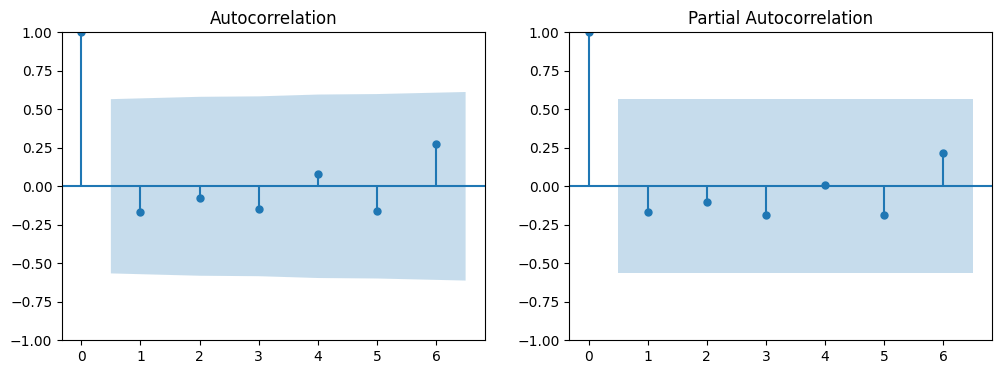

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

plot_acf(gdp_diff, ax=ax[0])
plot_pacf(gdp_diff, ax=ax[1])

plt.show()


Interpretation

PACF cutoff → p

ACF cutoff → q

differencing count → d

Auto ARIMA (recommended) This automatically selects best p,d,q.

In [ ]:
auto_model = pm.auto_arima(df['GDP'],
                           seasonal=False,
                           stepwise=True,
                           trace=True)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.28 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=284.003, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=286.015, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=286.533, Time=0.20 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=292.724, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.15 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 0.734 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   13
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -140.001
Date:                Thu, 05 Feb 2026   AIC                            284.003
Time:                        17:15:18   BIC                            284.972
Sample:                             0   HQIC                           283.643
                        

Fit ARIMA manually

In [ ]:
model = ARIMA(df['GDP'], order=(0,1,0))   # Replaced with best (p,d,q) from auto_arima
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                    GDP   No. Observations:                   13
Model:                 ARIMA(0, 1, 0)   Log Likelihood                -145.362
Date:                Thu, 05 Feb 2026   AIC                            292.724
Time:                        17:16:49   BIC                            293.209
Sample:                             0   HQIC                           292.545
                                 - 13                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      1.791e+09   1.41e+09      1.268      0.205   -9.78e+08    4.56e+09
Ljung-Box (L1) (Q):                   0.42   Jarque-Bera (JB):                 2.21
Prob(Q):                              0.52   Pr

Diagnostics

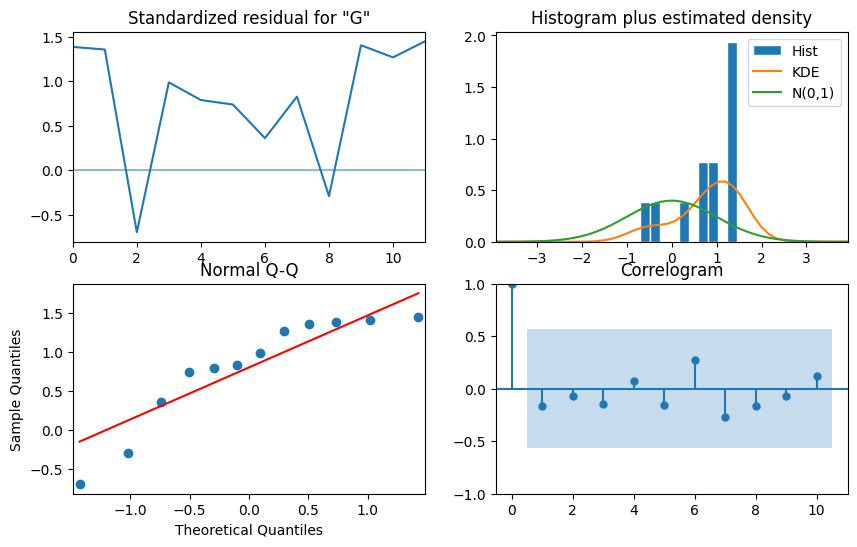

In [ ]:
model_fit.plot_diagnostics(figsize=(10,6))
plt.show()


Check:

residuals ≈ white noise

normal distribution

no autocorrelation

Forecast

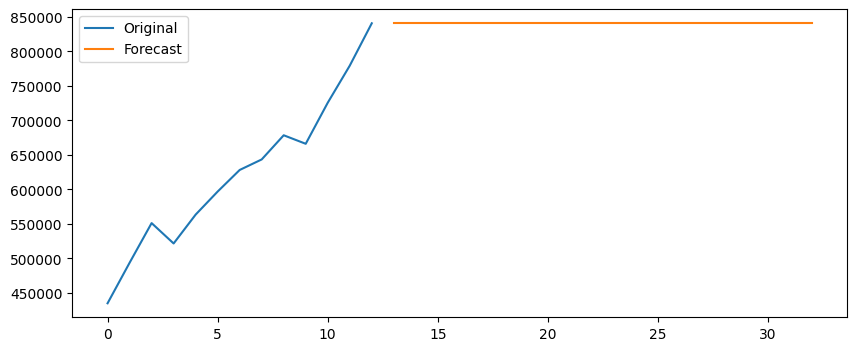

In [ ]:
n_steps = 20

forecast = model_fit.forecast(steps=n_steps)

plt.figure(figsize=(10,4))
plt.plot(df['GDP'], label='Original')
plt.plot(range(len(df['GDP']), len(df['GDP'])+n_steps), forecast, label='Forecast')
plt.legend()
plt.show()

Train/Test evaluation

In [ ]:
train_size = int(len(df['GDP'])*0.8)

train = df['GDP'][:train_size]
test = df['GDP'][train_size:]

model = ARIMA(train, order=(0,1,0))
model_fit = model.fit()

pred = model_fit.forecast(steps=len(test))

from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(test, pred))

print("RMSE:", rmse)

RMSE: 124979.75007442872
